In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

In [2]:
import os

dataset_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", len(dirs))
    print("Files:", len(files))
    print("-"*50)

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Folders: 4
Files: 5
--------------------------------------------------
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1
Folders: 0
Files: 5000
--------------------------------------------------
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1
Folders: 0
Files: 5000
--------------------------------------------------
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2
Folders: 0
Files: 5015
--------------------------------------------------
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_2
Folders: 0
Files: 5015
--------------------------------------------------


In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"
)

print(df.head())
print(df.columns)
print(df.shape)

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')
(10015, 7)


In [4]:
print(df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


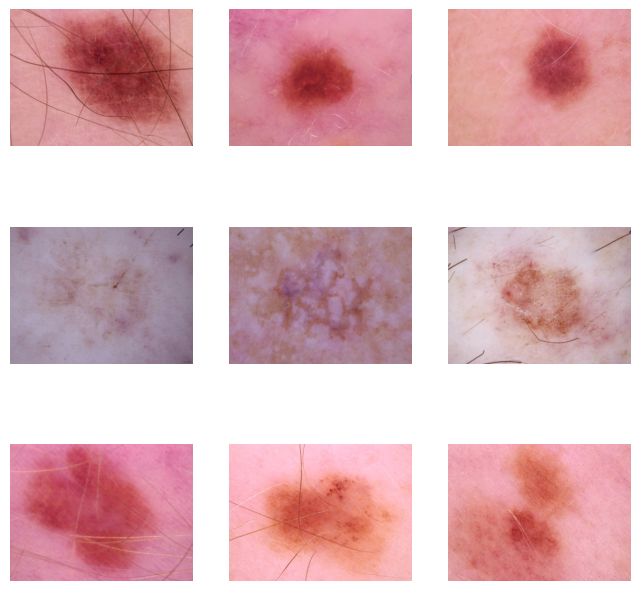

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

image_dir = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"

sample_files = os.listdir(image_dir)[:9]

fig, axes = plt.subplots(3,3, figsize=(8,8))

for ax, file in zip(axes.flatten(), sample_files):
    img = Image.open(os.path.join(image_dir,file))
    ax.imshow(img)
    ax.axis("off")

plt.show()

In [6]:
from PIL import Image
import os

img = Image.open(
    os.path.join(image_dir, sample_files[0])
)

print(img.size)

(600, 450)


In [7]:
print("Unique images:", df["image_id"].nunique())
print("Unique lesions:", df["lesion_id"].nunique())

Unique images: 10015
Unique lesions: 7470


In [8]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from collections import Counter

# --- 1. The Patched Pandas-Driven Dataset Class ---
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        
        # CHANGED: We now pull the exact absolute path that we mapped in the DataLoader function
        self.file_paths = self.df['path'].tolist()
        self.labels = self.df['label_idx'].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Lazy loading the image directly from the verified file path
        image = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


# --- 2. The Leak-Proof & Multi-Folder Data Ingestion Pipeline ---
def prepare_skin_cancer_dataloaders(dataset_root, csv_path, batch_size=32):
    print("Parsing HAM10000 metadata and locating image files...")
    
    # 1. Build the global image lookup dictionary across BOTH folders
    image_lookup = {}
    for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
        folder_path = os.path.join(dataset_root, folder)
        if os.path.exists(folder_path):
            for fname in os.listdir(folder_path):
                if fname.endswith('.jpg'):
                    image_id = fname.replace(".jpg", "")
                    image_lookup[image_id] = os.path.join(folder_path, fname)
                    
    print(f"Successfully mapped {len(image_lookup)} image files from disk.")

    # 2. Load CSV and map string classes to integers
    df = pd.read_csv(csv_path)
    classes = sorted(df['dx'].unique().tolist())
    df['label_idx'] = df['dx'].map(lambda x: classes.index(x))
    
    # 3. CHANGED: Inject the absolute file paths into the DataFrame
    df['path'] = df['image_id'].map(image_lookup)
    
    # Drop any rows where the image file was somehow missing from the dataset folders
    missing = df['path'].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} images in CSV were not found in folders. Dropping them.")
        df = df.dropna(subset=['path'])
    
    print(f"\nDiscovered 7 Skin Cancer Classes: {classes}")
    
    # 4. Isolate Unique Lesions to Prevent Data Leakage
    lesion_df = df.groupby('lesion_id').first().reset_index()
    
    # 5. Stratified Split on LESIONS (70% Train, 15% Val, 15% Test)
    train_lesions, temp_lesions, _, temp_classes = train_test_split(
        lesion_df['lesion_id'], lesion_df['label_idx'], 
        test_size=0.30, stratify=lesion_df['label_idx'], random_state=42
    )
    val_lesions, test_lesions = train_test_split(
        temp_lesions, test_size=0.50, stratify=temp_classes, random_state=42
    )

    # 6. Map the split lesions back to their original images
    train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
    val_df = df[df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
    test_df = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)

    print(f"\nSplits complete (Image Count): {len(train_df)} Train | {len(val_df)} Val | {len(test_df)} Test images.")

    # 7. Transforms (Standardized to 128x128 for the ResNet/DCGAN)
    resnet_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 8. Create Datasets and DataLoaders (Notice we don't pass image_dir anymore)
    train_dataset = HAM10000Dataset(train_df, transform=resnet_transform)
    val_dataset = HAM10000Dataset(val_df, transform=resnet_transform)
    test_dataset = HAM10000Dataset(test_df, transform=resnet_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader, test_loader, classes, train_df

In [9]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class BaselineResNet(nn.Module):
    # CHANGED: Default num_classes from 4 to 7 for HAM10000
    def __init__(self, num_classes=7):
        super(BaselineResNet, self).__init__()
        
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # 1. Freeze the entire backbone first
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # 2. Selective Fine-Tuning: Unfreeze Layer 4 to learn dermatology-specific features (Skin Lesions)
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
            
     # 3. Upgraded MLP Classification Head
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),                  # Heavy dropout on the raw ResNet features
            nn.Linear(num_ftrs, 128),         # Hidden layer for dermatological feature capacity
            nn.ReLU(),                        # Non-linear activation
            nn.Dropout(0.3),                  # Lighter dropout before final prediction
            nn.Linear(128, num_classes)       # Final 7-class output
        )

    def forward(self, x):
        return self.backbone(x)

    def print_trainable_parameters(self):
        """Utility to verify exactly how much of the network is updating."""
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"Total Parameters: {total:,}")
        print(f"Trainable Parameters: {trainable:,} ({(trainable/total)*100:.2f}%)")

# Optional: Run this script directly to test the architecture
if __name__ == "__main__":
    model = BaselineResNet()
    model.print_trainable_parameters()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s] 


Total Parameters: 11,243,079
Trainable Parameters: 8,460,295 (75.25%)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_baseline():
    set_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    # 1. CHANGED: New HAM10000 Paths for multi-folder lookup
    dataset_root = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
    csv_path = f"{dataset_root}/HAM10000_metadata.csv"
    
    # 2. CHANGED: Call the new skin cancer dataloader
    train_loader, val_loader, test_loader, classes, train_df = prepare_skin_cancer_dataloaders(dataset_root, csv_path, batch_size=32)

    # Nicely Formatted Class Distribution
    print("\n--- Training Set Class Distribution ---")
    train_counts = Counter(train_loader.dataset.labels)
    for i, cls in enumerate(classes):
        print(f"{cls:20s}: {train_counts[i]} images")

    model = BaselineResNet(num_classes=len(classes)).to(device)
    
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    epochs = 10
    best_val_loss = float("inf")
    
    print("\n--- Starting Day 1 Baseline Training ---")
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # Validation Phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_baseline.pth")
            print("  -> Saved new best model (Loss improved)!")

    # Evaluation & Explicit Extraction
    print("\n--- Day 1 Baseline Metrics (Test Set) ---")
    model.load_state_dict(torch.load("best_baseline.pth"))
    model.eval()
    
    torch.save(history, "baseline_history.pt")
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    report_dict = classification_report(all_labels, all_preds, target_names=classes, digits=4, output_dict=True)
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    
    # 3. CHANGED: Target the new skin cancer minority class ('df')
    minority_class = 'df'
            
    # The Portfolio Motivation Printout
    print("\n" + "="*50)
    print("DAY 1 PROBLEM STATEMENT METRICS (SKIN CANCER):")
    if minority_class in classes:
        print(f"Minority Class ('{minority_class}') Recall: {report_dict[minority_class]['recall']:.4f}")
    else:
        print(f"Warning: Could not find '{minority_class}' class in dataset folders.")
    
    print(f"Macro Avg F1-Score:       {report_dict['macro avg']['f1-score']:.4f}")
    print("="*50)

if __name__ == "__main__":
    train_baseline()

Executing on: cuda
Parsing HAM10000 metadata and locating image files...
Successfully mapped 10015 image files from disk.

Discovered 7 Skin Cancer Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Splits complete (Image Count): 6981 Train | 1532 Val | 1502 Test images.

--- Training Set Class Distribution ---
akiec               : 222 images
bcc                 : 361 images
bkl                 : 772 images
df                  : 71 images
mel                 : 773 images
nv                  : 4683 images
vasc                : 99 images

--- Starting Day 1 Baseline Training ---
Epoch 01/10 | Train Loss: 0.9001 Acc: 0.6834 | Val Loss: 0.6922 Acc: 0.7598
  -> Saved new best model (Loss improved)!
Epoch 02/10 | Train Loss: 0.5639 Acc: 0.7932 | Val Loss: 0.6375 Acc: 0.7826
  -> Saved new best model (Loss improved)!
Epoch 03/10 | Train Loss: 0.3579 Acc: 0.8744 | Val Loss: 0.6386 Acc: 0.7859
Epoch 04/10 | Train Loss: 0.1968 Acc: 0.9341 | Val Loss: 0.7703 Acc: 0.7768
Epoch 05/10 | T

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_experiment_2_weighted():
    set_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing Experiment 2 (Weighted Loss) on: {device}")

    # 1. HAM10000 Paths
    dataset_root = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
    csv_path = f"{dataset_root}/HAM10000_metadata.csv"
    
    # 2. Load Data
    train_loader, val_loader, test_loader, classes, train_df = prepare_skin_cancer_dataloaders(dataset_root, csv_path, batch_size=32)

    # 3. Class Distribution
    print("\n--- Training Set Class Distribution ---")
    train_counts = Counter(train_loader.dataset.labels)
    for i, cls in enumerate(classes):
        print(f"{cls:20s}: {train_counts[i]} images")

    # 4. Initialize Model
    model = BaselineResNet(num_classes=len(classes)).to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)

    # ==========================================
    # EXPERIMENT 2: THE SCIENTIFIC CONTROL
    # ==========================================
    total_samples = sum(train_counts.values())
    num_classes = len(classes)
    
    # Calculate balanced weights: Total / (Num_Classes * Class_Count)
    weights = []
    for i in range(num_classes):
        count = train_counts.get(i, 1) # Fallback to 1 to prevent division by zero
        weights.append(total_samples / (num_classes * count))
        
    weights_tensor = torch.FloatTensor(weights).to(device)
    
    print("\n--- Applied Class Weights ---")
    for i, cls in enumerate(classes):
        print(f"{cls:20s}: {weights[i]:.4f}")

    # Pass the weights to the loss function
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    # ==========================================    
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    epochs = 10
    best_val_loss = float("inf")
    
    print("\n--- Starting Experiment 2 Training ---")
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # Validation Phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Save under a different name to protect your baseline
            torch.save(model.state_dict(), "best_weighted_model.pth")
            print("  -> Saved new best weighted model!")

    # 5. Evaluation & Explicit Extraction
    print("\n--- Experiment 2 Metrics (Test Set) ---")
    model.load_state_dict(torch.load("best_weighted_model.pth"))
    model.eval()
    
    torch.save(history, "weighted_history.pt")
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    report_dict = classification_report(all_labels, all_preds, target_names=classes, digits=4, output_dict=True)
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    
    # Target the skin cancer minority class ('df')
    minority_class = 'df'
            
    # The Portfolio Motivation Printout
    print("\n" + "="*50)
    print("EXPERIMENT 2: WEIGHTED LOSS METRICS:")
    if minority_class in classes:
        print(f"Minority Class ('{minority_class}') Recall: {report_dict[minority_class]['recall']:.4f}")
    else:
        print(f"Warning: Could not find '{minority_class}' class in dataset folders.")
    
    print(f"Macro Avg F1-Score:       {report_dict['macro avg']['f1-score']:.4f}")
    print("="*50)

# Execute the new experiment
if __name__ == "__main__":
    train_experiment_2_weighted()

Executing Experiment 2 (Weighted Loss) on: cuda
Parsing HAM10000 metadata and locating image files...
Successfully mapped 10015 image files from disk.

Discovered 7 Skin Cancer Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Splits complete (Image Count): 6981 Train | 1532 Val | 1502 Test images.

--- Training Set Class Distribution ---
akiec               : 222 images
bcc                 : 361 images
bkl                 : 772 images
df                  : 71 images
mel                 : 773 images
nv                  : 4683 images
vasc                : 99 images

--- Applied Class Weights ---
akiec               : 4.4923
bcc                 : 2.7626
bkl                 : 1.2918
df                  : 14.0463
mel                 : 1.2901
nv                  : 0.2130
vasc                : 10.0736

--- Starting Experiment 2 Training ---
Epoch 01/10 | Train Loss: 1.5737 Acc: 0.4867 | Val Loss: 1.1139 Acc: 0.6051
  -> Saved new best weighted model!
Epoch 02/10 | Train Loss: 0.93

Experiemnt 2.5 With the help of classical Augumentation

In [12]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import random
import numpy as np

# =====================================================================
# 1. ISOLATED DATASET CLASS
# =====================================================================
class HAM10000_Augmented_Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.file_paths = self.df['path'].tolist()
        self.labels = self.df['label_idx'].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# =====================================================================
# 2. ISOLATED DATALOADER (Hardcoded with Strong Augmentation)
# =====================================================================
def prepare_AUGMENTED_dataloaders(dataset_root, csv_path, batch_size=32):
    print("Parsing HAM10000 metadata for Experiment 2.5...")
    
    # Map image paths
    image_lookup = {}
    for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
        folder_path = os.path.join(dataset_root, folder)
        if os.path.exists(folder_path):
            for fname in os.listdir(folder_path):
                if fname.endswith('.jpg'):
                    image_id = fname.replace(".jpg", "")
                    image_lookup[image_id] = os.path.join(folder_path, fname)
                    
    # Read CSV and drop missing
    df = pd.read_csv(csv_path)
    classes = sorted(df['dx'].unique().tolist())
    df['label_idx'] = df['dx'].map(lambda x: classes.index(x))
    df['path'] = df['image_id'].map(image_lookup)
    df = df.dropna(subset=['path'])
    
    # Lesion-level Stratified Split
    lesion_df = df.groupby('lesion_id').first().reset_index()
    train_lesions, temp_lesions, _, temp_classes = train_test_split(
        lesion_df['lesion_id'], lesion_df['label_idx'], 
        test_size=0.30, stratify=lesion_df['label_idx'], random_state=42
    )
    val_lesions, test_lesions = train_test_split(
        temp_lesions, test_size=0.50, stratify=temp_classes, random_state=42
    )

    train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
    val_df = df[df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
    test_df = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)

    # ---> THE STRONG CLASSICAL AUGMENTATION (Train Only) <---
    train_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Apply specific transforms
    train_dataset = HAM10000_Augmented_Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000_Augmented_Dataset(val_df, transform=eval_transform)
    test_dataset = HAM10000_Augmented_Dataset(test_df, transform=eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader, test_loader, classes, train_df


# =====================================================================
# 3. EXPERIMENT 2.5: WEIGHTED LOSS + STRONG AUGMENTATION
# =====================================================================
def train_experiment_2_5_aug_weighted():
    # Set seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing Experiment 2.5 (Weighted Loss + Strong Aug) on: {device}")

    # Paths
    dataset_root = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
    csv_path = f"{dataset_root}/HAM10000_metadata.csv"
    
    # Call the new ISOLATED dataloader
    train_loader, val_loader, test_loader, classes, _ = prepare_AUGMENTED_dataloaders(dataset_root, csv_path, batch_size=32)

    train_counts = Counter(train_loader.dataset.labels)

    # Initialize Model (Assuming BaselineResNet is already defined in an earlier cell)
    model = BaselineResNet(num_classes=len(classes)).to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)

    # Apply Weights
    total_samples = sum(train_counts.values())
    num_classes = len(classes)
    weights = []
    for i in range(num_classes):
        count = train_counts.get(i, 1)
        weights.append(total_samples / (num_classes * count))
        
    weights_tensor = torch.FloatTensor(weights).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    
    epochs = 10
    best_val_loss = float("inf")
    
    print("\n--- Starting Experiment 2.5 Training ---")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_aug_weighted_model.pth")

    # Evaluation
    print("\n--- Experiment 2.5 Metrics (Test Set) ---")
    model.load_state_dict(torch.load("best_aug_weighted_model.pth"))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    report_dict = classification_report(all_labels, all_preds, target_names=classes, digits=4, output_dict=True)
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))
    
    minority_class = 'df'
    print("\n" + "="*50)
    print("EXPERIMENT 2.5: WEIGHTED LOSS + CLASSICAL AUGMENTATION:")
    if minority_class in classes:
        print(f"Minority Class ('{minority_class}') Recall: {report_dict[minority_class]['recall']:.4f}")
    
    print(f"Macro Avg F1-Score:       {report_dict['macro avg']['f1-score']:.4f}")
    print("="*50)

if __name__ == "__main__":
    train_experiment_2_5_aug_weighted()

Executing Experiment 2.5 (Weighted Loss + Strong Aug) on: cuda
Parsing HAM10000 metadata for Experiment 2.5...

--- Starting Experiment 2.5 Training ---
Epoch 01/10 | Train Loss: 1.6449 Acc: 0.4537 | Val Loss: 1.2022 Acc: 0.5496
Epoch 02/10 | Train Loss: 1.2108 Acc: 0.5989 | Val Loss: 1.1051 Acc: 0.5920
Epoch 06/10 | Train Loss: 0.9272 Acc: 0.6508 | Val Loss: 0.8446 Acc: 0.6488
Epoch 07/10 | Train Loss: 0.8854 Acc: 0.6687 | Val Loss: 0.8671 Acc: 0.6625
Epoch 08/10 | Train Loss: 0.8412 Acc: 0.6784 | Val Loss: 0.9611 Acc: 0.6175
Epoch 09/10 | Train Loss: 0.8090 Acc: 0.6925 | Val Loss: 0.8078 Acc: 0.6808
Epoch 10/10 | Train Loss: 0.7952 Acc: 0.6955 | Val Loss: 0.8442 Acc: 0.6749

--- Experiment 2.5 Metrics (Test Set) ---

Classification Report:
              precision    recall  f1-score   support

       akiec     0.4627    0.5962    0.5210        52
         bcc     0.5000    0.6620    0.5697        71
         bkl     0.4719    0.5030    0.4870       167
          df     0.2500    0.65

In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torchvision import transforms

# =====================================================================
# 1. DCGAN MINORITY DATALOADER
# =====================================================================
def get_gan_dataloader(train_df, minority_class='df', batch_size=32):
    print(f"Isolating '{minority_class}' class for GAN training...")
    minority_df = train_df[train_df['dx'] == minority_class].reset_index(drop=True)
    
    gan_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(), 
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
    ])
    
    gan_dataset = HAM10000_Augmented_Dataset(minority_df, transform=gan_transform)
    gan_loader = DataLoader(gan_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    return gan_loader

# =====================================================================
# 2. DCGAN ARCHITECTURE (WITH DROPOUT AMNESIA)
# =====================================================================
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3), # CHANGED: Added Dropout
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3), # CHANGED: Added Dropout
            
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3), # CHANGED: Added Dropout
            
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3), # CHANGED: Added Dropout
            
            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3), # CHANGED: Added Dropout
            
            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# =====================================================================
# 3. ADVERSARIAL TRAINING LOOP (3-TO-1 ASYMMETRIC UPDATES)
# =====================================================================
def train_dcgan():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training GAN on: {device}")

    dataset_root = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
    csv_path = f"{dataset_root}/HAM10000_metadata.csv"
    
    _, _, _, classes, train_df = prepare_AUGMENTED_dataloaders(dataset_root, csv_path, batch_size=32)
    
    batch_size = 16      
    nz = 100
    num_epochs = 1000    
    lr_D = 0.00005       # CHANGED: Extreme TTUR (D is very slow)
    lr_G = 0.0003        # G is 6x faster than D
    beta1 = 0.5
    
    dataloader = get_gan_dataloader(train_df, minority_class='df', batch_size=batch_size)

    netG = Generator(nz=nz, nc=3).to(device)
    netD = Discriminator(nc=3).to(device)
    netG.apply(weights_init)
    netD.apply(weights_init)

    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, 0.999))

    fixed_noise = torch.randn(16, nz, 1, 1, device=device)
    real_label = 0.9   
    fake_label = 0.0
    
    os.makedirs("gan_outputs", exist_ok=True)

    print("\nStarting 3-to-1 Asymmetric DCGAN Training Loop...")
    for epoch in range(num_epochs):
        for i, data in enumerate(dataloader, 0):
            
            real_images = data[0].to(device)
            b_size = real_images.size(0)
            
            # -----------------------------------------------------
            # 1. Update Discriminator (JUST ONCE)
            # -----------------------------------------------------
            netD.zero_grad()
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
            output = netD(real_images)
            errD_real = criterion(output, label)
            errD_real.backward()
            D_x = output.mean().item()

            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake_images = netG(noise)
            label.fill_(fake_label)
            
            output = netD(fake_images.detach())
            errD_fake = criterion(output, label)
            errD_fake.backward()
            D_G_z1 = output.mean().item()
            
            errD = errD_real + errD_fake
            optimizerD.step()

            # -----------------------------------------------------
            # 2. Update Generator (THREE TIMES per D update)
            # -----------------------------------------------------
            for _ in range(3):
                netG.zero_grad()
                noise = torch.randn(b_size, nz, 1, 1, device=device)
                fake_images = netG(noise)
                label.fill_(real_label) 
                
                output = netD(fake_images)
                errG = criterion(output, label)
                errG.backward()
                D_G_z2 = output.mean().item()
                
                optimizerG.step()

        if (epoch + 1) % 10 == 0:
            print(f"[{epoch+1}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} "
                  f"D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}")

        if ((epoch + 1) % 50 == 0) or (epoch == num_epochs - 1):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            vutils.save_image(fake, f"gan_outputs/fake_samples_epoch_{(epoch+1):04d}.png", normalize=True, nrow=4)
            torch.save(netG.state_dict(), f"gan_outputs/netG_epoch_{(epoch+1):04d}.pth")

if __name__ == "__main__":
    train_dcgan()

Training GAN on: cuda
Parsing HAM10000 metadata for Experiment 2.5...
Isolating 'df' class for GAN training...

Starting 3-to-1 Asymmetric DCGAN Training Loop...
[10/1000] Loss_D: 7.2863 Loss_G: 0.4253 D(x): 0.2112 D(G(z)): 0.8798 / 0.8516
[20/1000] Loss_D: 4.2439 Loss_G: 0.4618 D(x): 0.1901 D(G(z)): 0.7415 / 0.7548
[30/1000] Loss_D: 5.5687 Loss_G: 1.2457 D(x): 0.1010 D(G(z)): 0.9001 / 0.3435
[40/1000] Loss_D: 4.1932 Loss_G: 1.4326 D(x): 0.1440 D(G(z)): 0.7653 / 0.3629
[50/1000] Loss_D: 3.8015 Loss_G: 1.4038 D(x): 0.2548 D(G(z)): 0.6978 / 0.2877
[60/1000] Loss_D: 2.3168 Loss_G: 0.4691 D(x): 0.3591 D(G(z)): 0.5063 / 0.7392
[70/1000] Loss_D: 4.1348 Loss_G: 2.0799 D(x): 0.1184 D(G(z)): 0.6268 / 0.1559
[80/1000] Loss_D: 3.4899 Loss_G: 0.5152 D(x): 0.2948 D(G(z)): 0.6809 / 0.7514
[90/1000] Loss_D: 2.7481 Loss_G: 0.5720 D(x): 0.3784 D(G(z)): 0.7539 / 0.6451
[100/1000] Loss_D: 2.5721 Loss_G: 0.5647 D(x): 0.4301 D(G(z)): 0.6647 / 0.6868
[110/1000] Loss_D: 1.7674 Loss_G: 1.0213 D(x): 0.4890 D(G

In [14]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import random
import numpy as np

# =====================================================================
# EXPERIMENT 3: THE GENERATIVE HYBRID PIPELINE
# =====================================================================

# --- THE FIX: Custom Dataset to return standard integer labels ---
class FakeLesionDataset(Dataset):
    def __init__(self, images_tensor, label_idx):
        self.images = images_tensor
        self.label_idx = label_idx
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        # Returns (Tensor, Python int) exactly like the real dataset
        return self.images[idx], self.label_idx

def train_experiment_3_hybrid():
    # Set seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing Experiment 3 (DCGAN Hybrid Data) on: {device}")

    # 1. Load the Standard Real Data
    dataset_root = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
    csv_path = f"{dataset_root}/HAM10000_metadata.csv"
    train_loader_real, val_loader, test_loader, classes, _ = prepare_AUGMENTED_dataloaders(dataset_root, csv_path, batch_size=32)

    # 2. Setup the Generator & Load Final Weights
    nz = 100
    netG = Generator(nz=nz, nc=3).to(device)
    
    weights_path = "gan_outputs/netG_epoch_1000.pth" 
    netG.load_state_dict(torch.load(weights_path))
    netG.eval()
    print(f"\nLoaded GAN weights from: {weights_path}")

    # 3. Generate 400 Synthetic Dermatofibroma ('df') Images
    print("Synthesizing 400 new 'df' lesions...")
    df_class_idx = classes.index('df')
    num_fakes = 400
    batch_size_gen = 50
    fake_images_list = []

    normalize_resnet = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    with torch.no_grad():
        for _ in range(num_fakes // batch_size_gen):
            noise = torch.randn(batch_size_gen, nz, 1, 1, device=device)
            fakes = netG(noise)
            
            fakes = (fakes + 1) / 2.0  # Scale to [0, 1]
            
            for i in range(fakes.size(0)):
                fakes[i] = normalize_resnet(fakes[i])
                
            fake_images_list.append(fakes.cpu())

    # Combine synthetic images into a single tensor
    fake_tensors = torch.cat(fake_images_list, dim=0)

    # --- THE FIX APPLIED: Wrap fakes in the custom dataset ---
    fake_dataset = FakeLesionDataset(fake_tensors, df_class_idx)

    # 4. Merge Real Data + Fake Data into a Hybrid DataLoader
    hybrid_dataset = ConcatDataset([train_loader_real.dataset, fake_dataset])
    hybrid_loader = DataLoader(hybrid_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

    print("\n--- HYBRID Training Set Class Distribution ---")
    hybrid_counts = Counter(train_loader_real.dataset.labels)
    hybrid_counts[df_class_idx] += num_fakes
    for i, cls in enumerate(classes):
        print(f"{cls:20s}: {hybrid_counts[i]} images (Included Fakes if applicable)")

    # 5. Initialize ResNet Model
    model = BaselineResNet(num_classes=len(classes)).to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)

    # 6. Milder Weighted Loss
    total_samples = sum(hybrid_counts.values())
    num_classes = len(classes)
    weights = []
    for i in range(num_classes):
        count = hybrid_counts.get(i, 1)
        weight = np.sqrt(total_samples / (num_classes * count))
        weights.append(weight)
        
    weights_tensor = torch.FloatTensor(weights).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    
    epochs = 10
    best_val_loss = float("inf")
    
    print("\n--- Starting Experiment 3 (Hybrid Data) Training ---")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in hybrid_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        train_acc = correct / total
        train_loss = running_loss / len(hybrid_loader)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_hybrid_model.pth")

    # 7. Final Evaluation
    print("\n--- Experiment 3 Hybrid Metrics (Test Set) ---")
    model.load_state_dict(torch.load("best_hybrid_model.pth"))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    report_dict = classification_report(all_labels, all_preds, target_names=classes, digits=4, output_dict=True)
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))
    
    minority_class = 'df'
    print("\n" + "="*50)
    print("EXPERIMENT 3: HYBRID GENERATIVE PIPELINE:")
    if minority_class in classes:
        print(f"Minority Class ('{minority_class}') Recall:    {report_dict[minority_class]['recall']:.4f}")
        print(f"Minority Class ('{minority_class}') Precision: {report_dict[minority_class]['precision']:.4f}")
    
    print(f"Macro Avg F1-Score:             {report_dict['macro avg']['f1-score']:.4f}")
    print("="*50)

if __name__ == "__main__":
    train_experiment_3_hybrid()

Executing Experiment 3 (DCGAN Hybrid Data) on: cuda
Parsing HAM10000 metadata for Experiment 2.5...

Loaded GAN weights from: gan_outputs/netG_epoch_1000.pth
Synthesizing 400 new 'df' lesions...

--- HYBRID Training Set Class Distribution ---
akiec               : 222 images (Included Fakes if applicable)
bcc                 : 361 images (Included Fakes if applicable)
bkl                 : 772 images (Included Fakes if applicable)
df                  : 471 images (Included Fakes if applicable)
mel                 : 773 images (Included Fakes if applicable)
nv                  : 4683 images (Included Fakes if applicable)
vasc                : 99 images (Included Fakes if applicable)

--- Starting Experiment 3 (Hybrid Data) Training ---
Epoch 01/10 | Train Loss: 1.2163 Acc: 0.6708 | Val Loss: 0.7981 Acc: 0.7213
Epoch 02/10 | Train Loss: 0.9067 Acc: 0.7254 | Val Loss: 0.7194 Acc: 0.7520
Epoch 03/10 | Train Loss: 0.8397 Acc: 0.7439 | Val Loss: 0.7047 Acc: 0.7311
Epoch 04/10 | Train Loss: 0

In [15]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.3 MB/s eta 0:00:0000:010:01
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=eb0b6525542e8fc480311b10fe20d5b15396554a3c62051f5ed1b89e355b0631
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3

Running Grad-CAM on: cuda
Parsing HAM10000 metadata for Experiment 2.5...
Loaded best_hybrid_model.pth successfully.


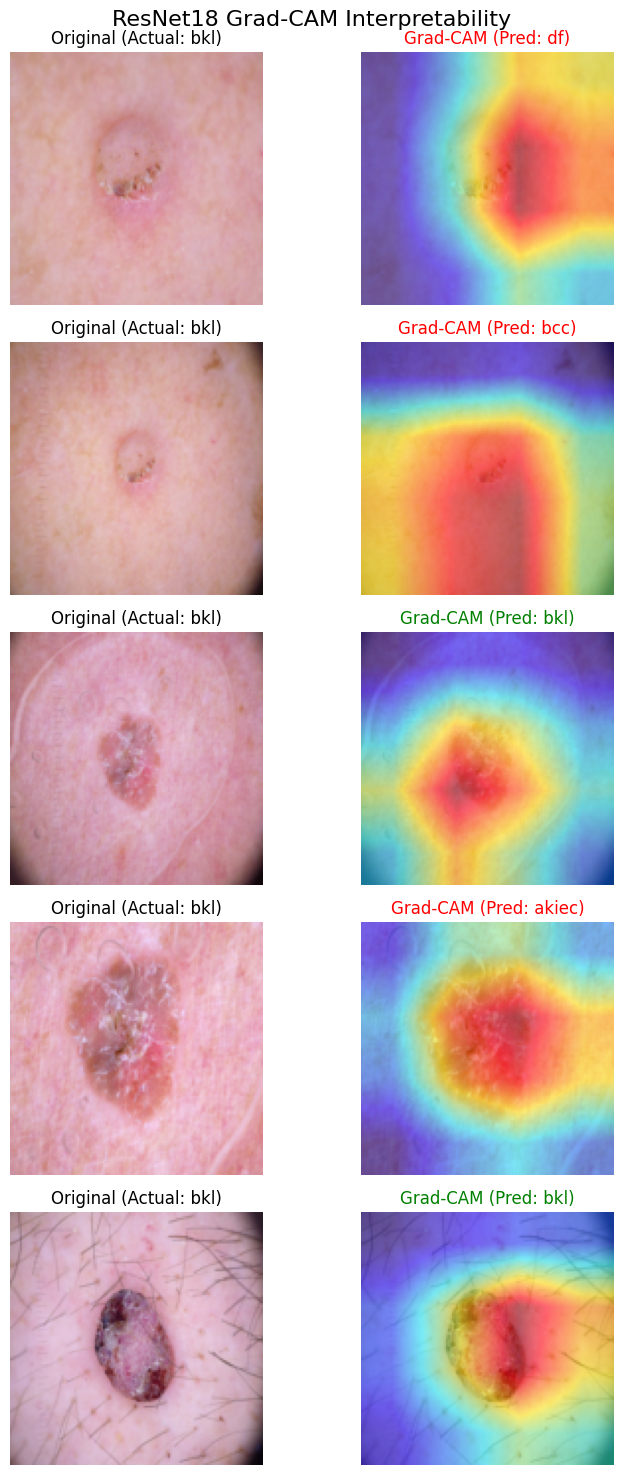

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def run_gradcam_interpretability():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running Grad-CAM on: {device}")

    # 1. Load Data
    dataset_root = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
    csv_path = f"{dataset_root}/HAM10000_metadata.csv"
    _, _, test_loader, classes, _ = prepare_AUGMENTED_dataloaders(dataset_root, csv_path, batch_size=32)
    
    # 2. Load Final Hybrid Model
    model = BaselineResNet(num_classes=len(classes)).to(device)
    model.load_state_dict(torch.load("best_hybrid_model.pth"))
    model.eval()
    print("Loaded best_hybrid_model.pth successfully.")

    # 3. Target the final convolutional layer of the ResNet
    target_layers = [model.backbone.layer4[-1]]

    # 4. Initialize Grad-CAM
    cam = GradCAM(model=model, target_layers=target_layers)

    # 5. Grab a batch of test images
    data_iter = iter(test_loader)
    test_images, test_labels = next(data_iter)
    
    # Let's look at the first 5 images
    num_images = 5
    test_images = test_images[:num_images].to(device)
    test_labels = test_labels[:num_images].cpu().numpy()

    # Get model predictions
    with torch.no_grad():
        outputs = model(test_images)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu().numpy()

    # 6. Un-normalize images for plotting (needs to be float32 in [0, 1] range)
    test_images_np = test_images.cpu().numpy().transpose(0, 2, 3, 1)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    unnorm_images = std * test_images_np + mean
    unnorm_images = np.clip(unnorm_images, 0, 1).astype(np.float32)

    # 7. Generate and Plot
    fig, axes = plt.subplots(num_images, 2, figsize=(8, 3 * num_images))
    fig.suptitle('ResNet18 Grad-CAM Interpretability', fontsize=16)

    for i in range(num_images):
        # We target the class the model actually predicted
        targets = [ClassifierOutputTarget(preds[i])]
        
        # Generate the heatmap for this specific image
        input_tensor = test_images[i].unsqueeze(0)
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        
        # Overlay the heatmap on the original image
        cam_image = show_cam_on_image(unnorm_images[i], grayscale_cam, use_rgb=True)
        
        actual_cls = classes[test_labels[i]]
        pred_cls = classes[preds[i]]
        title_color = "green" if actual_cls == pred_cls else "red"

        # Plot Original
        axes[i, 0].imshow(unnorm_images[i])
        axes[i, 0].set_title(f"Original (Actual: {actual_cls})")
        axes[i, 0].axis('off')

        # Plot Grad-CAM
        axes[i, 1].imshow(cam_image)
        axes[i, 1].set_title(f"Grad-CAM (Pred: {pred_cls})", color=title_color)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig("gradcam_results.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    run_gradcam_interpretability()